In [16]:
import warnings
from dataclasses import dataclass
from itertools import combinations, product
from typing import Dict, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import ExtraTreesClassifier, IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score
from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM, SVC
from sklearn.inspection import DecisionBoundaryDisplay

warnings.filterwarnings("ignore")

In [17]:
RANDOM_STATE = 42
TARGET_COL = "Outcome"

# Serology results, blood counts, temperature and fever duration separate the two Outcome
# classes almost perfectly (see 00_model), so every configuration below would score a tie.
# They are dropped to let the outlier methods be compared at all.
LEAKAGE_COLS = [
    "NS1",
    "IgG",
    "IgM",
    "Platelet_Count",
    "WBC_Count",
    "Body_Temperature",
    "Fever_Duration",
]

CATEGORICAL_COLS = ["Gender", "AreaType", "HouseType", "Joint_Pain"]

OUTLIER_METHODS = [
    "none",
    "isolation_forest",
    "local_outlier_factor",
    "one_class_svm",
    "elliptic_envelope",
]

In [18]:
from itertools import combinations
import numpy as np
import pandas as pd

def add_area_binning(df: pd.DataFrame, poverty_df: pd.DataFrame, n_bins: int = 5) -> pd.DataFrame:
    out = df.copy()

    areas = (
        out[["Area", "Outcome"]]
        .dropna(subset=["Area"])
        .groupby("Area", as_index=False)
        .agg(n_patients=("Outcome", "size"))
        .merge(poverty_df[["Area", "HCR_upper_2022"]], on="Area", how="left")
        .sort_values(["HCR_upper_2022", "Area"], kind="mergesort")
        .reset_index(drop=True)
    )

    def find_balanced_cuts(sizes, n_bins=5):
        sizes = np.asarray(sizes, dtype=float)
        cumulative = np.concatenate([[0], sizes.cumsum()])
        target = sizes.sum() / n_bins

        best_score, best_bounds = None, None
        for cuts in combinations(range(1, len(sizes)), n_bins - 1):
            bounds = (0,) + cuts + (len(sizes),)
            counts = np.diff(cumulative[list(bounds)])
            deviations = np.abs(counts - target)
            score = (deviations.max(), (deviations ** 2).sum())
            if best_score is None or score < best_score:
                best_score, best_bounds = score, bounds

        return list(best_bounds), best_score

    bounds, _ = find_balanced_cuts(areas["n_patients"].values, n_bins=n_bins)

    inner_edges = [
        round(
            (areas.loc[b - 1, "HCR_upper_2022"] + areas.loc[b, "HCR_upper_2022"]) / 2,
            3,
        )
        for b in bounds[1:-1]
    ]

    bin_edges = [-np.inf] + inner_edges + [np.inf]
    bin_labels = [f"Q{i}" for i in range(1, n_bins + 1)]

    area_to_hcr = poverty_df.set_index("Area")["HCR_upper_2022"]
    out["Area_HCR"] = out["Area"].map(area_to_hcr)
    out["Area_bin"] = pd.cut(
        out["Area_HCR"],
        bins=bin_edges,
        labels=bin_labels,
        ordered=True,
    )

    out['Area_bin_code'] = out['Area_bin'].cat.codes
    out = out.drop(columns=['Area_bin', 'Area_HCR'])
    # out = pd.get_dummies(out, columns=['Area_bin'], drop_first=True, dtype=int)
    # out = out.drop(columns=['Area_HCR'])

    return out


def add_age_binning(df: pd.DataFrame, balance_tolerance: float = 0.10) -> pd.DataFrame:
    """Add Age_bin using the same balanced-split logic from Feature_Engineering.ipynb."""
    out = df.copy()

    age_counts = (
        out.groupby("Age")
        .agg(n_patients=("Outcome", "size"), positive_rate=("Outcome", "mean"))
        .sort_index()
    )

    def enumerate_splits(n_groups, n_bins):
        return np.array(
            [(0,) + cuts + (n_groups,) for cuts in combinations(range(1, n_groups), n_bins - 1)],
            dtype=np.int32,
        )

    def score_splits(splits, group_sizes, group_positives):
        group_sizes = np.asarray(group_sizes, dtype=float)
        group_positives = np.asarray(group_positives, dtype=float)
        cum_n = np.concatenate([[0], group_sizes.cumsum()])
        cum_p = np.concatenate([[0], group_positives.cumsum()])

        n = np.diff(cum_n[splits], axis=1)
        p = np.diff(cum_p[splits], axis=1)
        total_n, total_p = group_sizes.sum(), group_positives.sum()
        target = total_n / (splits.shape[1] - 1)

        expected_pos = n * total_p / total_n
        expected_neg = n * (total_n - total_p) / total_n
        with np.errstate(divide="ignore", invalid="ignore"):
            chi2 = np.nan_to_num(
                (p - expected_pos) ** 2 / expected_pos + ((n - p) - expected_neg) ** 2 / expected_neg
            ).sum(axis=1)

        rates = np.divide(p, n, out=np.full_like(p, np.nan), where=n > 0)
        return {
            "n": n,
            "rates": rates,
            "balance_deviation": np.abs(n - target).max(axis=1),
            "rate_spread": np.nanmax(rates, axis=1) - np.nanmin(rates, axis=1),
            "chi2": chi2,
        }

    age_values = age_counts.index.to_numpy()
    age_sizes = age_counts["n_patients"].to_numpy()
    age_positives = out.groupby("Age")["Outcome"].sum().sort_index().to_numpy()

    splits = enumerate_splits(len(age_values), 5)
    scores = score_splits(splits, age_sizes, age_positives)

    tol = balance_tolerance * len(out) / 5
    allowed = np.where(scores["balance_deviation"] <= tol)[0]
    if len(allowed) == 0:
        raise ValueError("No age split satisfies the balance tolerance.")

    chosen = allowed[scores["chi2"][allowed].argmax()]
    age_bounds = splits[chosen]

    age_edges = [-np.inf] + [(age_values[b - 1] + age_values[b]) / 2 for b in age_bounds[1:-1]] + [np.inf]
    age_labels = [
        f"{age_values[age_bounds[i]]}-{age_values[age_bounds[i + 1] - 1]}"
        for i in range(5)
    ]

    out["Age_bin"] = pd.cut(out["Age"], bins=age_edges, labels=age_labels, ordered=True)
    # out["Age_bin_code"] = out["Age_bin"].cat.codes
    out = pd.get_dummies(out, columns=['Age_bin'], drop_first=True, dtype=int)
    # out = out.drop(columns=['Age_bin'])
    return out

In [19]:
@dataclass
class RunResult:
    outlier_method: str
    model_name: str
    recall: float
    f1: float
    train_rows: int


def load_data(
    path: str = "data.csv",
    poverty_path: str = "area_poverty_table.csv",
    ) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns=lambda col: col.strip())
    df = df.drop(columns=[col for col in LEAKAGE_COLS + ["District"] if col in df.columns])

    # poverty rate of the thana the patient lives in (see 03_Feature_Engineering)
    poverty = pd.read_csv(poverty_path)
    df["Area_HCR"] = df["Area"].map(poverty.set_index("Area")["HCR_upper_2022"])
    return df


def prepare_features(df: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:
    """Fill the missing values and one-hot encode the categorical columns.

    Every fill value comes from `reference` (the training + validation rows), so no statistic
    of the untouched test subset ever reaches the frames used below.
    """
    out = df.copy()

    # A missing Joint_Pain means the symptom was not reported (see 02_Missing_Values)
    out["Joint_Pain"] = out["Joint_Pain"].fillna("None")
    for col in out.select_dtypes(include="number"):
        out[col] = out[col].fillna(reference[col].median())
    for col in CATEGORICAL_COLS:
        out[col] = out[col].fillna(reference[col].mode()[0])

    return pd.get_dummies(out, columns=CATEGORICAL_COLS, drop_first=True, dtype=int)


def apply_binning(
    df: pd.DataFrame,
    poverty_path: str = "area_poverty_table.csv",
    ) -> pd.DataFrame:
    """The binning picked in 00_model: one ordinal Area column, one-hot Age bins.

    Area_HCR and the raw Age column are dropped, so only the binned versions reach the models.
    """
    poverty = pd.read_csv(poverty_path)
    df_binned = add_area_binning(df, poverty, n_bins=5)
    df_binned = add_age_binning(df_binned, balance_tolerance=0.10)
    return df_binned.drop(columns=["Area", "Age"])


def apply_outlier_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    method: str,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.Series]:
    if method == "none":
        return X_train.copy(), y_train.copy()

    if method == "isolation_forest":
        detector = IsolationForest(
            contamination=0.05,
            random_state=random_state,
            n_estimators=200,
        )
        labels = detector.fit_predict(X_train)

    elif method == "local_outlier_factor":
        detector = LocalOutlierFactor(
            n_neighbors=20,
            contamination=0.05,
        )
        labels = detector.fit_predict(X_train)

    elif method == "one_class_svm":
        detector = Pipeline([
            ("scaler", StandardScaler()),
            ("detector", OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)),
        ])
        labels = detector.fit_predict(X_train)

    elif method == "elliptic_envelope":
        detector = EllipticEnvelope(
            contamination=0.05,
            random_state=random_state,
        )
        labels = detector.fit_predict(X_train)

    else:
        raise ValueError(f"Unknown outlier method: {method}")

    mask = pd.Series(labels == 1, index=X_train.index)
    X_filtered = X_train.loc[mask].copy()
    y_filtered = y_train.loc[mask].copy()
    return X_filtered, y_filtered

In [20]:
def get_models() -> Dict[str, object]:
    return {
        "LogisticRegression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        "RandomForestClassifier": RandomForestClassifier(random_state=RANDOM_STATE),
        "ExtraTreesClassifier": ExtraTreesClassifier(random_state=RANDOM_STATE),
        "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "KNeighborsClassifier": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
        "SVC": Pipeline([("scaler", StandardScaler()), ("model", SVC())]),
    }


def split_train_val_test(
    df: pd.DataFrame,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """80 / 10 / 10 split with a fixed seed, so every notebook can rebuild the same subsets.

    The test subset is returned untouched and must not take part in any selection step.
    """
    df_dev, df_test = train_test_split(df, test_size=0.1, random_state=random_state)
    df_train, df_val = train_test_split(df_dev, test_size=1 / 9, random_state=random_state)
    return df_train, df_val, df_test


def evaluate_configuration(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    outlier_method: str,
    model_name: str,
    model: object,
    ) -> RunResult:
    X_train_f, y_train_f = apply_outlier_filter(X_train, y_train, outlier_method)

    estimator = clone(model)
    estimator.fit(X_train_f, y_train_f)
    y_pred = estimator.predict(X_val)

    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    return RunResult(
        outlier_method=outlier_method,
        model_name=model_name,
        recall=recall,
        f1=f1,
        train_rows=len(X_train_f),
    )


def run_full_search(df_train: pd.DataFrame, df_val: pd.DataFrame) -> pd.DataFrame:
    X_train = df_train.drop(columns=[TARGET_COL]).copy()
    y_train = df_train[TARGET_COL].copy()
    X_val = df_val.drop(columns=[TARGET_COL]).copy()
    y_val = df_val[TARGET_COL].copy()

    models = get_models()
    rows = []

    all_configs = list(product(OUTLIER_METHODS, models.items()))
    for outlier_method, model_info in tqdm(
        all_configs,
        total=len(all_configs),
        desc="Searching configs",
        unit="config",
    ):
        model_name, model = model_info
        result = evaluate_configuration(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            outlier_method=outlier_method,
            model_name=model_name,
            model=model,
        )
        rows.append(result.__dict__)

    results = pd.DataFrame(rows)
    results = results.sort_values(["recall", "f1"], ascending=[False, False]).reset_index(drop=True)
    return results


def print_best_configuration(results: pd.DataFrame) -> None:
    best = results.iloc[0]
    print("Best configuration based on recall (desc) then F1 (desc):")
    print(f"- Outlier method: {best['outlier_method']}")
    print(f"- Model: {best['model_name']}")
    print(f"- Recall: {best['recall']:.4f}")
    print(f"- F1: {best['f1']:.4f}")
    print(f"- Training rows after outlier filtering: {int(best['train_rows'])}")


In [21]:
df_raw = load_data()

# 80 / 10 / 10, fixed seed on both splits: the test subset is put aside and never touched again
df_train_raw, df_val_raw, df_test_raw = split_train_val_test(df_raw, RANDOM_STATE)

# imputation, encoding and binning are all fitted on the training + validation rows only
df_dev_raw = pd.concat([df_train_raw, df_val_raw], axis=0)
df_dev = apply_binning(prepare_features(df_dev_raw, reference=df_dev_raw))
df_train = df_dev.loc[df_train_raw.index]
df_val = df_dev.loc[df_val_raw.index]

print(f"train: {len(df_train)} | val: {len(df_val)} | test (untouched): {len(df_test_raw)}")

results = run_full_search(df_train, df_val)
print_best_configuration(results)
results.head(10)

train: 800 | val: 100 | test (untouched): 100


Searching configs: 100%|██████████| 30/30 [00:03<00:00,  9.25config/s]

Best configuration based on recall (desc) then F1 (desc):
- Outlier method: local_outlier_factor
- Model: GradientBoostingClassifier
- Recall: 0.9800
- F1: 0.9608
- Training rows after outlier filtering: 760


,outlier_method,model_name,recall,f1,train_rows
0,local_outlier_factor,GradientBoostingClassifier,0.98,0.960784,760
1,none,RandomForestClassifier,0.96,0.950495,800
2,none,SVC,0.96,0.950495,800
3,isolation_forest,LogisticRegression,0.96,0.950495,760
4,isolation_forest,RandomForestClassifier,0.96,0.950495,760
5,isolation_forest,SVC,0.96,0.950495,760
6,local_outlier_factor,LogisticRegression,0.96,0.950495,760
7,local_outlier_factor,SVC,0.96,0.950495,760
8,one_class_svm,LogisticRegression,0.96,0.950495,711
9,one_class_svm,SVC,0.96,0.950495,711


In [22]:
# Build the transformed dataframe for the best-performing configuration and describe it
best = results.iloc[0]

X_train = df_train.drop(columns=[TARGET_COL]).copy()
y_train = df_train[TARGET_COL].copy()

X_train_best, y_train_best = apply_outlier_filter(
    X_train, y_train, best["outlier_method"], RANDOM_STATE
)

best_train_df = X_train_best.copy()
best_train_df[TARGET_COL] = y_train_best.values

print("Best configuration used for dataframe description:")
print(
    best[["outlier_method", "model_name", "recall", "f1"]]
        .to_string()
)

display(best_train_df.describe(include="all").T)
print(f"Shape after preprocessing: {best_train_df.shape}")

Best configuration used for dataframe description:
outlier_method          local_outlier_factor
model_name        GradientBoostingClassifier
recall                                  0.98
f1                                  0.960784


,count,mean,std,min,25%,50%,75%,max
Headache,760.0,0.564474,0.496152,0.0,0.0,1.0,1.0,1.0
Retro_Orbital_Pain,760.0,0.384211,0.486728,0.0,0.0,0.0,1.0,1.0
Myalgia,760.0,0.457895,0.498552,0.0,0.0,0.0,1.0,1.0
Rash,760.0,0.367105,0.482333,0.0,0.0,0.0,1.0,1.0
Gender_Male,760.0,0.465789,0.499157,0.0,0.0,0.0,1.0,1.0
AreaType_Undeveloped,760.0,0.497368,0.500322,0.0,0.0,0.0,1.0,1.0
HouseType_Other,760.0,0.336842,0.472942,0.0,0.0,0.0,1.0,1.0
HouseType_Tinshed,760.0,0.325000,0.468683,0.0,0.0,0.0,1.0,1.0
Joint_Pain_None,760.0,0.494737,0.500302,0.0,0.0,0.0,1.0,1.0
Joint_Pain_Severe,760.0,0.340789,0.474287,0.0,0.0,0.0,1.0,1.0


Shape after preprocessing: (760, 16)


We can see that linear regression with CGA binning and outlier detection works out the best. Let us try to pick out the most performative combinations and try to tune them to their best performance.

In [28]:
# Fix model based on previous best search
base_model = get_models()["GradientBoostingClassifier"]


def apply_outlier_filter_with_params(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    method: str,
    params: dict,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.Series]:
    if method == "isolation_forest":
        detector = IsolationForest(random_state=random_state, **params)
        labels = detector.fit_predict(X_train)
    elif method == "local_outlier_factor":
        detector = LocalOutlierFactor(**params)
        labels = detector.fit_predict(X_train)
    elif method == "one_class_svm":
        detector = Pipeline([
            ("scaler", StandardScaler()),
            ("detector", OneClassSVM(**params)),
        ])
        labels = detector.fit_predict(X_train)
    elif method == "elliptic_envelope":
        detector = EllipticEnvelope(random_state=random_state, **params)
        labels = detector.fit_predict(X_train)
    else:
        raise ValueError(f"Unsupported outlier method: {method}")

    mask = pd.Series(labels == 1, index=X_train.index)
    return X_train.loc[mask].copy(), y_train.loc[mask].copy()


outlier_param_grid = {
    "isolation_forest": {
        "contamination": [0.03, 0.05, 0.08],
        "n_estimators": [100, 200, 400],
        "max_samples": ["auto", 0.8],
    },
    "local_outlier_factor": {
        "n_neighbors": [10, 20, 35],
        "contamination": [0.03, 0.05, 0.08],
        "leaf_size": [30, 50],
    },
    "one_class_svm": {
        "kernel": ["rbf"],
        "nu": [0.03, 0.05, 0.08],
        "gamma": ["scale", 0.05, 0.1],
    },
    "elliptic_envelope": {
        "contamination": [0.03, 0.05, 0.08],
        "support_fraction": [None, 0.8, 0.9],
    },
}

# the folds below are cut out of the training + validation rows only
X_dev = df_dev.drop(columns=[TARGET_COL]).copy()
y_dev = df_dev[TARGET_COL].copy()

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuning_rows = []

search_space = []
for method, grid in outlier_param_grid.items():
    for params in ParameterGrid(grid):
        search_space.append((method, params))

In [29]:
for method, params in tqdm(search_space, desc="Tuning outlier methods", unit="setting"):
    fold_recall = []
    fold_f1 = []
    fold_train_rows = []

    for train_idx, val_idx in cv.split(X_dev):
        X_train_cv = X_dev.iloc[train_idx].copy()
        X_val_cv = X_dev.iloc[val_idx].copy()
        y_train_cv = y_dev.iloc[train_idx].copy()
        y_val_cv = y_dev.iloc[val_idx].copy()

        X_train_f, y_train_f = apply_outlier_filter_with_params(
            X_train_cv, y_train_cv, method, params, RANDOM_STATE
        )

        estimator = clone(base_model)
        estimator.fit(X_train_f, y_train_f)
        y_pred = estimator.predict(X_val_cv)

        fold_recall.append(recall_score(y_val_cv, y_pred))
        fold_f1.append(f1_score(y_val_cv, y_pred))
        fold_train_rows.append(len(X_train_f))

    tuning_rows.append({
        "outlier_method": method,
        "params": params,
        "mean_recall": float(np.mean(fold_recall)),
        "std_recall": float(np.std(fold_recall)),
        "mean_f1": float(np.mean(fold_f1)),
        "std_f1": float(np.std(fold_f1)),
        "mean_train_rows": float(np.mean(fold_train_rows)),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["mean_recall", "mean_f1"], ascending=[False, False]
).reset_index(drop=True)

best_tuned = tuning_results.iloc[0]
print("Best tuned outlier setup (5-fold CV, LogisticRegression):")
print(f"- Outlier method: {best_tuned['outlier_method']}")
print(f"- Params: {best_tuned['params']}")
print(f"- Mean recall: {best_tuned['mean_recall']:.4f} +/- {best_tuned['std_recall']:.4f}")
print(f"- Mean F1: {best_tuned['mean_f1']:.4f} +/- {best_tuned['std_f1']:.4f}")
print(f"- Mean training rows after outlier filtering: {best_tuned['mean_train_rows']:.1f}")

tuning_results.head(10)

Tuning outlier methods: 100%|██████████| 54/54 [00:41<00:00,  1.29setting/s]

Best tuned outlier setup (5-fold CV, LogisticRegression):
- Outlier method: local_outlier_factor
- Params: {'contamination': 0.05, 'leaf_size': 30, 'n_neighbors': 20}
- Mean recall: 0.9667 +/- 0.0110
- Mean F1: 0.9595 +/- 0.0117
- Mean training rows after outlier filtering: 684.2


,outlier_method,params,mean_recall,std_recall,mean_f1,std_f1,mean_train_rows
0,local_outlier_factor,"{'contamination': 0.05, 'leaf_size': 30, 'n_ne...",0.966684,0.011011,0.959523,0.011667,684.2
1,one_class_svm,"{'gamma': 0.05, 'kernel': 'rbf', 'nu': 0.03}",0.954340,0.016376,0.950956,0.011275,654.0
2,local_outlier_factor,"{'contamination': 0.03, 'leaf_size': 30, 'n_ne...",0.954079,0.012930,0.953950,0.012247,698.0
3,isolation_forest,"{'contamination': 0.03, 'max_samples': 0.8, 'n...",0.952000,0.013003,0.951763,0.008961,698.0
4,elliptic_envelope,"{'contamination': 0.08, 'support_fraction': 0.9}",0.951528,0.011486,0.952517,0.012762,662.0
5,local_outlier_factor,"{'contamination': 0.03, 'leaf_size': 50, 'n_ne...",0.949968,0.013581,0.950811,0.011311,698.0
6,local_outlier_factor,"{'contamination': 0.08, 'leaf_size': 50, 'n_ne...",0.949829,0.012411,0.955834,0.012486,662.0
7,isolation_forest,"{'contamination': 0.03, 'max_samples': 0.8, 'n...",0.949778,0.011120,0.950631,0.009239,698.0
8,local_outlier_factor,"{'contamination': 0.05, 'leaf_size': 50, 'n_ne...",0.949639,0.009653,0.950669,0.010664,684.0
9,one_class_svm,"{'gamma': 0.05, 'kernel': 'rbf', 'nu': 0.08}",0.947884,0.015930,0.948587,0.009311,648.0


`LocalOutlierFactor` works the best on our dataset, since it is one of the few outlier methods that can deal with a lot of categorical data. Other potential candidates could be elliptic envelope. These two do not really rely on distance for identifying outliers, unlike e.g. one class SVM.

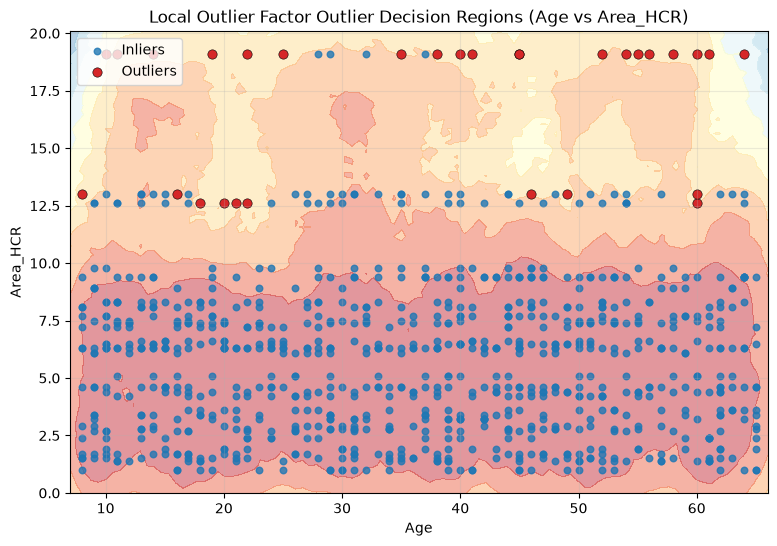

Detected outliers: 30 / 900 (3.33%)


In [39]:
# 2D feature space for outlier visualization
columns = ["Age", "Area_HCR"]
X_2d = df_dev_raw[columns].copy()

lof = LocalOutlierFactor(
    n_neighbors=20,
    leaf_size=30,
    contamination=0.05,
    novelty=True
 )
lof.fit(X_2d)

pred_labels = lof.predict(X_2d)  # 1=inlier, -1=outlier
is_outlier = pred_labels == -1

fig, ax = plt.subplots(figsize=(9, 6))

DecisionBoundaryDisplay.from_estimator(
    estimator=lof,
    X=X_2d,
    response_method="decision_function",
    plot_method="contourf",
    cmap="RdYlBu_r",
    alpha=0.45,
    ax=ax,
 )

ax.scatter(
    *[X_2d.loc[~is_outlier, col] for col in columns],
    s=22,
    c="#1f77b4",
    alpha=0.8,
    label="Inliers",
 )
ax.scatter(
    *[X_2d.loc[is_outlier, col] for col in columns],
    s=45,
    c="#d62728",
    edgecolor="black",
    linewidth=0.4,
    label="Outliers",
 )

ax.set_title("Local Outlier Factor Outlier Decision Regions ({} vs {})".format(columns[0], columns[1]))
ax.set_xlabel(columns[0])
ax.set_ylabel(columns[1])
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f"Detected outliers: {is_outlier.sum()} / {len(X_2d)} ({is_outlier.mean() * 100:.2f}%)")

At this point I thought that we lose 20-32 training rows during outlier method evaluation, since the filtered outlier rows are now not used neither in training phase nor in the testing phase. Since the outliers are not some malformed rows that our production model would never encounter (or should not encounter), I decided to recreate the pipeline, but now include the filtered outliers in the testing set to see which combination would result in a better production performance.

In [40]:
def apply_outlier_filter_with_params(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    method: str,
    params: dict,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    if method == "isolation_forest":
        detector = IsolationForest(random_state=random_state, **params)
        labels = detector.fit_predict(X_train)
    elif method == "local_outlier_factor":
        detector = LocalOutlierFactor(**params)
        labels = detector.fit_predict(X_train)
    elif method == "one_class_svm":
        detector = Pipeline([
            ("scaler", StandardScaler()),
            ("detector", OneClassSVM(**params)),
        ])
        labels = detector.fit_predict(X_train)
    elif method == "elliptic_envelope":
        detector = EllipticEnvelope(random_state=random_state, **params)
        labels = detector.fit_predict(X_train)
    else:
        raise ValueError(f"Unsupported outlier method: {method}")

    inlier_mask = pd.Series(labels == 1, index=X_train.index)
    outlier_mask = ~inlier_mask

    X_train_inliers = X_train.loc[inlier_mask].copy()
    y_train_inliers = y_train.loc[inlier_mask].copy()

    X_train_outliers = X_train.loc[outlier_mask].copy()
    y_train_outliers = y_train.loc[outlier_mask].copy()

    # Evaluate on the original validation fold plus outliers removed from training.
    X_test_augmented = pd.concat([X_test.copy(), X_train_outliers], axis=0)
    y_test_augmented = pd.concat([y_test.copy(), y_train_outliers], axis=0)

    return (
        X_train_inliers,
        y_train_inliers,
        X_test_augmented,
        y_test_augmented,
        X_train_outliers,
        y_train_outliers,
    )


for method, params in tqdm(search_space, desc="Tuning outlier methods", unit="setting"):
    fold_recall = []
    fold_f1 = []
    fold_train_rows = []
    fold_outliers_added = []
    fold_eval_rows = []

    for train_idx, val_idx in cv.split(X_dev):
        X_train_cv = X_dev.iloc[train_idx].copy()
        X_val_cv = X_dev.iloc[val_idx].copy()
        y_train_cv = y_dev.iloc[train_idx].copy()
        y_val_cv = y_dev.iloc[val_idx].copy()

        (
            X_train_f,
            y_train_f,
            X_val_aug,
            y_val_aug,
            X_train_out,
            _,
        ) = apply_outlier_filter_with_params(
            X_train_cv,
            y_train_cv,
            X_val_cv,
            y_val_cv,
            method,
            params,
            RANDOM_STATE,
        )

        estimator = clone(base_model)
        estimator.fit(X_train_f, y_train_f)
        y_pred = estimator.predict(X_val_aug)

        fold_recall.append(recall_score(y_val_aug, y_pred))
        fold_f1.append(f1_score(y_val_aug, y_pred))
        fold_train_rows.append(len(X_train_f))
        fold_outliers_added.append(len(X_train_out))
        fold_eval_rows.append(len(X_val_aug))

    tuning_rows.append({
        "outlier_method": method,
        "params": params,
        "mean_recall": float(np.mean(fold_recall)),
        "std_recall": float(np.std(fold_recall)),
        "mean_f1": float(np.mean(fold_f1)),
        "std_f1": float(np.std(fold_f1)),
        "mean_train_rows": float(np.mean(fold_train_rows)),
        "mean_outliers_added_to_test": float(np.mean(fold_outliers_added)),
        "mean_eval_rows": float(np.mean(fold_eval_rows)),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["mean_recall", "mean_f1"], ascending=[False, False]
).reset_index(drop=True)

best_tuned = tuning_results.iloc[0]
print("Best tuned outlier setup (5-fold CV, LogisticRegression, including outliers in test set):")
print(f"- Outlier method: {best_tuned['outlier_method']}")
print(f"- Params: {best_tuned['params']}")
print(f"- Mean recall: {best_tuned['mean_recall']:.4f} +/- {best_tuned['std_recall']:.4f}")
print(f"- Mean F1: {best_tuned['mean_f1']:.4f} +/- {best_tuned['std_f1']:.4f}")
print(f"- Mean training rows after outlier filtering: {best_tuned['mean_train_rows']:.1f}")
print(f"- Mean outlier rows moved to test fold: {best_tuned['mean_outliers_added_to_test']:.1f}")
print(f"- Mean validation/test rows after merge: {best_tuned['mean_eval_rows']:.1f}")

tuning_results.head(10)

Tuning outlier methods: 100%|██████████| 54/54 [00:40<00:00,  1.32setting/s]

Best tuned outlier setup (5-fold CV, LogisticRegression, including outliers in test set):
- Outlier method: local_outlier_factor
- Params: {'contamination': 0.05, 'leaf_size': 30, 'n_neighbors': 20}
- Mean recall: 0.9667 +/- 0.0110
- Mean F1: 0.9595 +/- 0.0117
- Mean training rows after outlier filtering: 684.2
- Mean outlier rows moved to test fold: nan
- Mean validation/test rows after merge: nan


,outlier_method,params,mean_recall,std_recall,mean_f1,std_f1,mean_train_rows,mean_outliers_added_to_test,mean_eval_rows
0,local_outlier_factor,"{'contamination': 0.05, 'leaf_size': 30, 'n_ne...",0.966684,0.011011,0.959523,0.011667,684.2,NaN,NaN
1,one_class_svm,"{'gamma': 0.05, 'kernel': 'rbf', 'nu': 0.03}",0.957578,0.013616,0.951604,0.009806,654.0,66.0,246.0
2,one_class_svm,"{'gamma': 'scale', 'kernel': 'rbf', 'nu': 0.05}",0.957394,0.010588,0.953216,0.010244,646.0,74.0,254.0
3,isolation_forest,"{'contamination': 0.03, 'max_samples': 0.8, 'n...",0.956861,0.014661,0.954097,0.010069,698.0,22.0,202.0
4,one_class_svm,"{'gamma': 0.05, 'kernel': 'rbf', 'nu': 0.03}",0.954340,0.016376,0.950956,0.011275,654.0,NaN,NaN
5,local_outlier_factor,"{'contamination': 0.03, 'leaf_size': 30, 'n_ne...",0.954079,0.012930,0.953950,0.012247,698.0,NaN,NaN
6,isolation_forest,"{'contamination': 0.03, 'max_samples': 0.8, 'n...",0.953141,0.012339,0.952137,0.010085,698.0,22.0,202.0
7,elliptic_envelope,"{'contamination': 0.08, 'support_fraction': 0.9}",0.953023,0.007985,0.933860,0.018715,662.0,58.0,238.0
8,isolation_forest,"{'contamination': 0.03, 'max_samples': 0.8, 'n...",0.952000,0.013003,0.951763,0.008961,698.0,NaN,NaN
9,one_class_svm,"{'gamma': 0.05, 'kernel': 'rbf', 'nu': 0.08}",0.951978,0.011108,0.951839,0.005679,648.0,72.0,252.0


It looks like the R2 metric has shown a decent improvement, while MAE has increased a tiny bit. Looking at the decision boundary of the best performing outlier method, it looks like OneClassSVM tends to overfitting, and creates a wavy decision boundary. Moreover, since we add the outleirs to the test set, the outliers are now much closer to the main cluster and to the decision boundary, so our model is inherently more likely to have a higher accuracy for those points, which artificially inflates our metrics.

The conclusion is that we should prefer a more generalized approach to the outlier method (previously evaluated EllipticEnvelope), which will give us more objective metrics

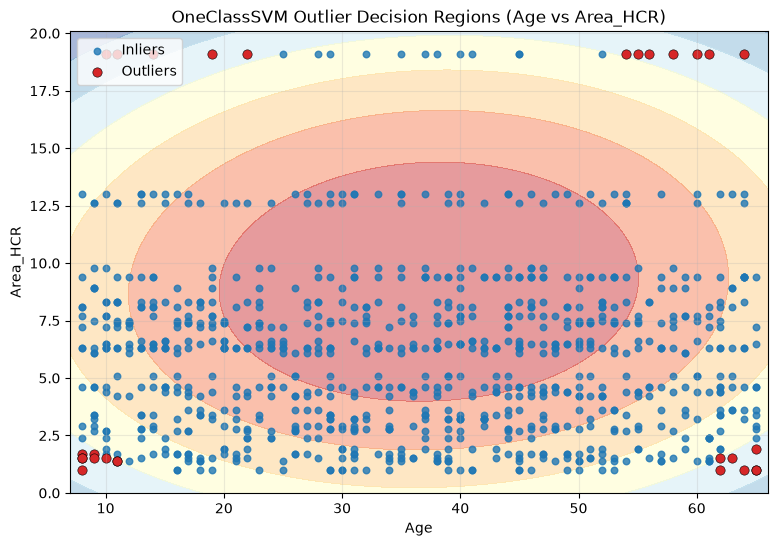

Detected outliers: 28 / 900 (3.11%)


In [42]:
# 2D feature space for outlier visualization
X_2d = df_dev_raw[["Age", "Area_HCR"]].copy()

one_class_cvm = Pipeline([
    ("scaler", StandardScaler()),
    ("detector", OneClassSVM(gamma=0.05, kernel="rbf", nu=0.03)),
 ])
one_class_cvm.fit(X_2d)

pred_labels = one_class_cvm.predict(X_2d)  # 1=inlier, -1=outlier
is_outlier = pred_labels == -1

fig, ax = plt.subplots(figsize=(9, 6))

DecisionBoundaryDisplay.from_estimator(
    estimator=one_class_cvm,
    X=X_2d,
    response_method="decision_function",
    plot_method="contourf",
    cmap="RdYlBu_r",
    alpha=0.45,
    ax=ax,
 )

ax.scatter(
    X_2d.loc[~is_outlier, "Age"],
    X_2d.loc[~is_outlier, "Area_HCR"],
    s=22,
    c="#1f77b4",
    alpha=0.8,
    label="Inliers",
 )
ax.scatter(
    X_2d.loc[is_outlier, "Age"],
    X_2d.loc[is_outlier, "Area_HCR"],
    s=45,
    c="#d62728",
    edgecolor="black",
    linewidth=0.4,
    label="Outliers",
 )

ax.set_title("OneClassSVM Outlier Decision Regions (Age vs Area_HCR)")
ax.set_xlabel("Age")
ax.set_ylabel("Area_HCR")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f"Detected outliers: {is_outlier.sum()} / {len(X_2d)} ({is_outlier.mean() * 100:.2f}%)")